# Dataset Preprocessing & Holdout-Aware Seasonal-Phase Labeling
**Project:** Synthetic Precipitation Generation via Time-Series Diffusion (ImagenFew)  
**Objective:** Establish the canonical chronological holdout split and fit the 4-level seasonal-phase conditioning index strictly on training years (2000–2007) with zero data leakage into holdouts (2008 validation, 2009 test). Includes intra-day mode pooling, minimum-duration dwell-time smoothing (`smooth_hmm_states_min_duration`), and multi-scale transition matrices supporting context lengths from `seq_len = 24` (2 hours) up to `seq_len = 288` (24 hours).

In [1]:
import os
import sys
import glob
import json
import hashlib
import pickle
from math import floor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

# Set plotting aesthetics
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif'
})

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'rainfall')
SPLITS_DIR = os.path.join(DATA_DIR, 'splits')
os.makedirs(SPLITS_DIR, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)
print("Output Splits Directory:", SPLITS_DIR)

Project Root: /Users/tanyawarrier/Desktop/projects/ImagenFew
Data Directory: /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall
Output Splits Directory: /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall/splits


## 1. Data Ingestion & Integrity Verification
We load the canonical 10-year 5-minute precipitation dataset (`data/rainfall/real_rainfall_data.csv`) and compute its SHA-256 checksum to ensure provenance.

In [3]:
csv_path = os.path.join(DATA_DIR, 'real_rainfall_data.csv')
assert os.path.exists(csv_path), f"File not found: {csv_path}"

# Compute SHA-256 checksum
hasher = hashlib.sha256()
with open(csv_path, 'rb') as f:
    while chunk := f.read(65536):
        hasher.update(chunk)
raw_sha256 = hasher.hexdigest()

df_raw = pd.read_csv(csv_path)
print("Raw dataset loaded successfully.")
print(f"Total rows: {len(df_raw):,}")
print(f"SHA-256: {raw_sha256}")
print(f"Columns: {list(df_raw.columns)}")
print(df_raw.head(3))

Raw dataset loaded successfully.
Total rows: 1,051,200
SHA-256: 8f888e31edde837cb4fddad0c184e9ee15ca887690e21065dd75a06efeb3fffa
Columns: ['date', 'avg_rainfall']
                  date  avg_rainfall
0  2000-01-01 00:00:00         0.005
1  2000-01-01 00:05:00         0.000
2  2000-01-01 00:10:00         0.000


## 2. Standardized Calendar Indexing
Each year consists of exactly 365 calendar days ($105,120$ 5-minute intervals). We construct:
- `interval_of_day`: Step index within the 24-hour day ($0$ to $287$).
- `annual_interval_idx`: Cumulative 5-minute step index within the 365-day year ($0$ to $105,119$).
- `day_of_year`: Calendar day ($1$ to $365$).

In [5]:
# Calculate annual 5-minute interval index (0 to 105,119) for each year
df_raw['datetime'] = pd.to_datetime(df_raw['date'])
df_raw['year'] = df_raw['datetime'].dt.year
df_raw['annual_interval_idx'] = df_raw.groupby('year').cumcount()
df_raw['interval_of_day'] = df_raw['annual_interval_idx'] % 288
df_raw['day_of_year'] = (df_raw['annual_interval_idx'] // 288) + 1
df_raw['rainfall_intensity'] = df_raw['avg_rainfall']

# Sanity check: Ensure each year has exactly 105,120 rows (no leap day artifacts)
year_counts = df_raw.groupby('year').size()
print("Rows per calendar year:")
print(year_counts)
assert (year_counts == 105120).all(), "Error: Inconsistent interval counts per year!"
assert df_raw['annual_interval_idx'].max() == 105119, "Error: annual_interval_idx should max at 105,119!"
print("Calendar indexing validated: Strictly 105,120 intervals per year.")

Rows per calendar year:
year
2000    105120
2001    105120
2002    105120
2003    105120
2004    105120
2005    105120
2006    105120
2007    105120
2008    105120
2009    105120
dtype: int64
Calendar indexing validated: Strictly 105,120 intervals per year.


## 3. Chronological Train, Validation, and Test Partitioning
We partition the dataset into chronological holdouts:
- **Train (2000–2007):** 8 years ($840,960$ intervals)
- **Validation (2008):** 1 year ($105,120$ intervals)
- **Test (2009):** 1 year ($105,120$ intervals)

In [7]:
train_mask = (df_raw['year'] >= 2000) & (df_raw['year'] <= 2007)
val_mask = (df_raw['year'] == 2008)
test_mask = (df_raw['year'] == 2009)

df_train = df_raw[train_mask].copy()
df_val = df_raw[val_mask].copy()
df_test = df_raw[test_mask].copy()

splits = {'Train (2000-2007)': df_train, 'Val (2008)': df_val, 'Test (2009)': df_test}
for name, s_df in splits.items():
    print(f"{name:20s}: {len(s_df):,} intervals | Date range: {s_df['datetime'].min()} to {s_df['datetime'].max()}")

assert len(df_train) == 840960, f"Expected 840,960 train rows, got {len(df_train)}"
assert len(df_val) == 105120, f"Expected 105,120 val rows, got {len(df_val)}"
assert len(df_test) == 105120, f"Expected 105,120 test rows, got {len(df_test)}"
print("Splits partition 100% of data with 0 overlapping timestamps.")

Train (2000-2007)   : 840,960 intervals | Date range: 2000-01-01 00:00:00 to 2007-12-31 23:55:00
Val (2008)          : 105,120 intervals | Date range: 2008-01-01 00:00:00 to 2008-12-31 23:55:00
Test (2009)         : 105,120 intervals | Date range: 2009-01-01 00:00:00 to 2009-12-31 23:55:00
Splits partition 100% of data with 0 overlapping timestamps.


## 4. Train-Only Climatological Mean Intensity Smoothing
To prevent data contamination, the 105,120-interval climatological profile (`clim_105120`) is computed **strictly across the 8 training years (2000–2007)**.
For each interval slot $i \in [0, 105119]$, we calculate the 8-year mean precipitation, then apply a 14-day rolling mean window ($4,032$ intervals) with centered alignment.

In [9]:
# Aggregate strictly over training years into 105,120-slot profile
clim_105120 = df_train.groupby('annual_interval_idx').agg(
    mean_intensity=('avg_rainfall', 'mean'),
    median_intensity=('avg_rainfall', 'median'),
    day_of_year=('day_of_year', 'first')
).reset_index().sort_values('annual_interval_idx')

# 14-day rolling mean smoothing (14 * 288 = 4,032 steps)
SMOOTH_WINDOW = 14 * 288
clim_105120['mean_intensity_smooth'] = clim_105120['mean_intensity'].rolling(
    window=SMOOTH_WINDOW, min_periods=1, center=True
).mean()

print(f"Training climatological profile shape: {clim_105120.shape} (Expected: 105,120)")
print("Summary statistics of smoothed feature:")
print(clim_105120[['mean_intensity', 'mean_intensity_smooth']].describe().T)

Training climatological profile shape: (105120, 5) (Expected: 105,120)
Summary statistics of smoothed feature:
                          count      mean  ...       75%       max
mean_intensity         105120.0  0.006750  ...  0.007188  0.694375
mean_intensity_smooth  105120.0  0.006743  ...  0.007661  0.013792

[2 rows x 8 columns]


## 5. Fit 4-State GaussianHMM on Training Climatology
We standardize the smoothed 1-D training feature using `StandardScaler` and train a 4-state `GaussianHMM` with full covariance ($200$ iterations, `random_state=42`).
States are re-ordered monotonically so that:
- **Phase 0:** Lowest smoothed climatological intensity (Dry Baseline)
- **Phase 1:** Moderate smoothed intensity
- **Phase 2:** Heavy Convective smoothed intensity
- **Phase 3:** Peak Cloudburst smoothed intensity

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(clim_105120[['mean_intensity_smooth']])

# Fit 4-state HMM
N_STATES = 4
hmm_model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type='full',
    n_iter=200,
    random_state=42
)
hmm_model.fit(X_train_scaled)

# Predict raw sequence
clim_105120['raw_state'] = hmm_model.predict(X_train_scaled)

# Order states monotonically by ascending mean smoothed intensity
state_means = clim_105120.groupby('raw_state')['mean_intensity_smooth'].mean().sort_values()
state_order_map = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}
clim_105120['hmm_state'] = clim_105120['raw_state'].map(state_order_map)

print("HMM Fitting on Training Split (2000-2007) Complete!")
print("State Mapping (Raw -> Ascending Intensity):", state_order_map)
print("Initial 105,120 state transitions:", np.sum(clim_105120['hmm_state'].values[:-1] != clim_105120['hmm_state'].values[1:]))

HMM Fitting on Training Split (2000-2007) Complete!
State Mapping (Raw -> Ascending Intensity): {0: 0, 2: 1, 1: 2, 3: 3}
Initial 105,120 state transitions: 73


## 6. Intra-Day Mode Assignment
To prevent rapid intra-day state transitions ("chattering") within a single 24-hour cycle, we assign each calendar day (288 consecutive 5-minute intervals) its modal state, matching the v2 protocol.

In [13]:
# Extract calendar day index (0 to 364)
clim_105120['day_idx'] = clim_105120['annual_interval_idx'] // 288

# Replace each day's states with the day's mode state
daily_modes = clim_105120.groupby('day_idx')['hmm_state'].agg(lambda s: s.value_counts().index[0])
clim_105120['hmm_state'] = clim_105120['day_idx'].map(daily_modes).astype(int)

# Verify strictly 1 constant state per day
unique_per_day = clim_105120.groupby('day_idx')['hmm_state'].nunique()
varying_days = (unique_per_day > 1).sum()

print("=" * 60)
print(f"Days with >1 HMM State after mode assignment: {varying_days} (0.00%)")
print(f"Constant State Days: {(unique_per_day == 1).sum():,} / {len(unique_per_day):,}")
print("State Distribution across intervals:")
print(clim_105120['hmm_state'].value_counts().sort_index())
print("Transitions after daily mode assignment:", np.sum(clim_105120['hmm_state'].values[:-1] != clim_105120['hmm_state'].values[1:]))
print("=" * 60)

Days with >1 HMM State after mode assignment: 0 (0.00%)
Constant State Days: 365 / 365
State Distribution across intervals:
hmm_state
0    33408
1    34272
2    26784
3    10656
Name: count, dtype: int64
Transitions after daily mode assignment: 50


## 7. Run Duration & Transient Spells Analysis (`runs_df`)
We perform Run-Length Encoding (RLE) across the 105,120 interval profile to measure the duration of contiguous seasonal-phase spells and determine the post-processing smoothing threshold.

HMM STATE RUN DURATION & TRANSIENT SPELLS ANALYSIS
Total Continuous State Spells in Year : 51
Average Spell Duration                : 7.16 days
Median Spell Duration                 : 4.00 days
Spells lasting < 14 days              : 44 / 51 (86.3%)
Spells lasting < 7 days               : 34 / 51 (66.7%)
Spells lasting < 3 days (Bleak Blips) : 17 / 51 (33.3%)


<string>:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


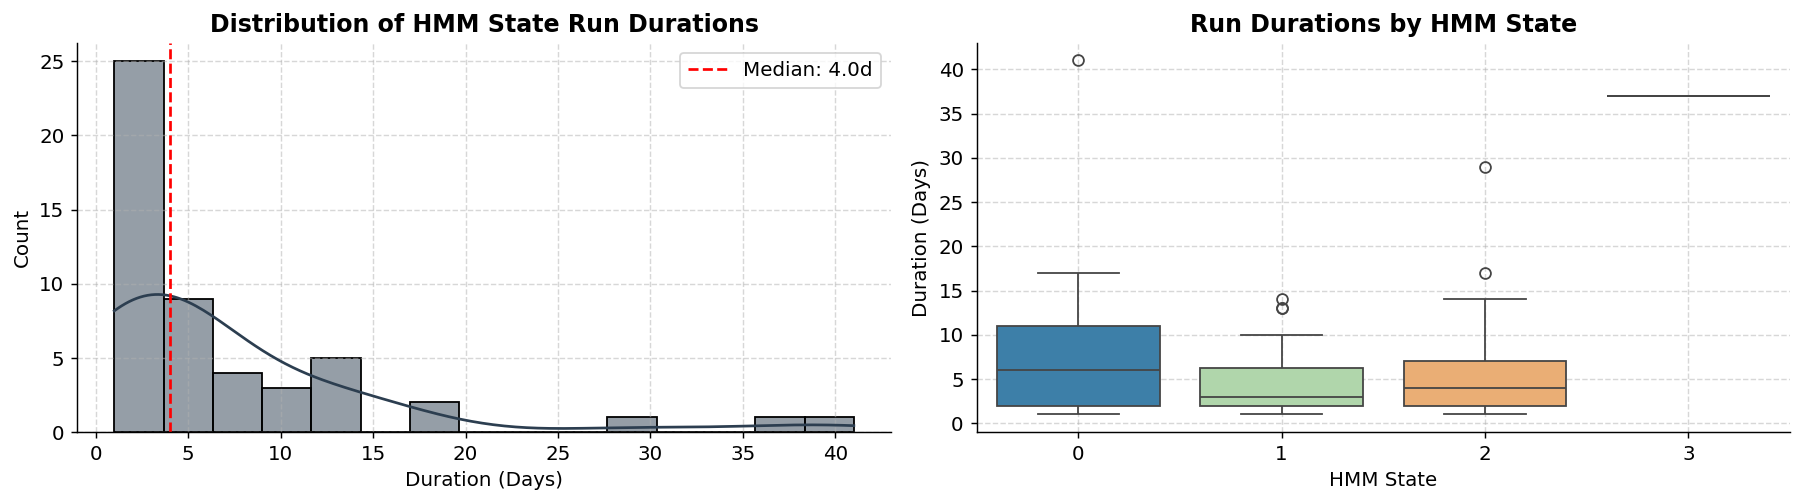

In [15]:
# 1. Extract 105,120 state sequence
states = clim_105120['hmm_state'].values

# 2. Run-Length Encoding (RLE) to identify continuous state spells
runs = []
current_st = states[0]
start_idx = 0

for i in range(1, len(states)):
    if states[i] != current_st or i == len(states) - 1:
        end_idx = i if states[i] != current_st else i + 1
        dur_steps = end_idx - start_idx
        dur_days = dur_steps / 288.0
        start_day = (start_idx / 288.0) + 1.0
        end_day = (end_idx / 288.0) + 1.0
        
        runs.append({
            'state': int(current_st),
            'start_idx': start_idx,
            'end_idx': end_idx,
            'start_day': round(start_day, 2),
            'end_day': round(end_day, 2),
            'dur_steps': dur_steps,
            'dur_hours': round(dur_steps * 5 / 60.0, 1),
            'dur_days': round(dur_days, 2),
        })
        current_st = states[i]
        start_idx = i

runs_df = pd.DataFrame(runs)

# 3. Summary & Filters for Short / Bleak Runs
short_14d = runs_df[runs_df['dur_days'] < 14.0]
short_7d  = runs_df[runs_df['dur_days'] < 7.0]
short_3d  = runs_df[runs_df['dur_days'] < 3.0]

print("=" * 80)
print("HMM STATE RUN DURATION & TRANSIENT SPELLS ANALYSIS")
print("=" * 80)
print(f"Total Continuous State Spells in Year : {len(runs_df)}")
print(f"Average Spell Duration                : {runs_df['dur_days'].mean():.2f} days")
print(f"Median Spell Duration                 : {runs_df['dur_days'].median():.2f} days")
print(f"Spells lasting < 14 days              : {len(short_14d)} / {len(runs_df)} ({len(short_14d)/len(runs_df)*100:.1f}%)")
print(f"Spells lasting < 7 days               : {len(short_7d)} / {len(runs_df)} ({len(short_7d)/len(runs_df)*100:.1f}%)")
print(f"Spells lasting < 3 days (Bleak Blips) : {len(short_3d)} / {len(runs_df)} ({len(short_3d)/len(runs_df)*100:.1f}%)")
print("=" * 80)

# Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#2b83ba', '#abdda4', '#fdae61', '#d73027']

sns.histplot(runs_df['dur_days'], bins=15, kde=True, ax=ax1, color='#2c3e50')
ax1.axvline(runs_df['dur_days'].median(), color='red', linestyle='--', label=f'Median: {runs_df["dur_days"].median():.1f}d')
ax1.set_title('Distribution of HMM State Run Durations', fontweight='bold')
ax1.set_xlabel('Duration (Days)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

sns.boxplot(x='state', y='dur_days', data=runs_df, ax=ax2, palette=colors, hue='state', legend=False)
ax2.set_title('Run Durations by HMM State', fontweight='bold')
ax2.set_xlabel('HMM State')
ax2.set_ylabel('Duration (Days)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. HMM State Post-Processing Filter (`smooth_hmm_states_min_duration`)
We apply the minimum-duration dwell-time smoothing filter to merge any state spells lasting fewer than $\text{min\_days} = \lfloor\text{median duration}\rfloor$ days into their dominant neighbor state.

In [17]:
from math import floor

def smooth_hmm_states_min_duration(state_seq, min_days=3, steps_per_day=288):
    """
    Post-processing filter: Merges any state spell lasting < min_days 
    into the surrounding dominant state (eliminates 1-day and 2-day flickers).
    """
    print("Minimum days:", min_days)
    min_steps = int(min_days * steps_per_day)
    s = state_seq.copy()
    
    changed = True
    while changed:
        changed = False
        # 1. Identify all contiguous runs
        runs = []
        cur_st = s[0]
        st_idx = 0
        
        for i in range(1, len(s)):
            if s[i] != cur_st or i == len(s) - 1:
                en_idx = i if s[i] != cur_st else i + 1
                runs.append((cur_st, st_idx, en_idx, en_idx - st_idx))
                cur_st = s[i]
                st_idx = i
        
        # 2. Find and merge the shortest spell below threshold
        for idx, (st_val, start, end, dur) in enumerate(runs):
            if dur < min_steps:
                prev_st = runs[idx - 1][0] if idx > 0 else (runs[idx + 1][0] if idx < len(runs) - 1 else st_val)
                next_st = runs[idx + 1][0] if idx < len(runs) - 1 else prev_st
                
                # If State A -> State B -> State A, revert B back to A
                if prev_st == next_st:
                    s[start:end] = prev_st
                else:
                    # Merge into the longer adjacent neighbor
                    prev_dur = runs[idx - 1][3] if idx > 0 else 0
                    next_dur = runs[idx + 1][3] if idx < len(runs) - 1 else 0
                    s[start:end] = prev_st if prev_dur >= next_dur else next_st
                    
                changed = True
                break
                
    return s

# --- Apply to 105,120 Profile ---
clim_105120['hmm_state_raw'] = clim_105120['hmm_state']
clim_105120['hmm_state'] = smooth_hmm_states_min_duration(
    clim_105120['hmm_state_raw'].values, 
    min_days=floor(runs_df['dur_days'].median())
)

print("=" * 60)
print("HMM STATE POST-PROCESSING COMPLETE")
print("=" * 60)
print("State transitions before smoothing:", np.sum(clim_105120['hmm_state_raw'].values[:-1] != clim_105120['hmm_state_raw'].values[1:]))
print("State transitions after smoothing :", np.sum(clim_105120['hmm_state'].values[:-1] != clim_105120['hmm_state'].values[1:]))
print("=" * 60)

Minimum days: 4
HMM STATE POST-PROCESSING COMPLETE
State transitions before smoothing: 50
State transitions after smoothing : 21


## 9. Visualizing Segmentation Before vs. After Post-Processing
We compare the 365-day state sequences before and after smoothing, confirming the removal of transient flickers.

<string>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


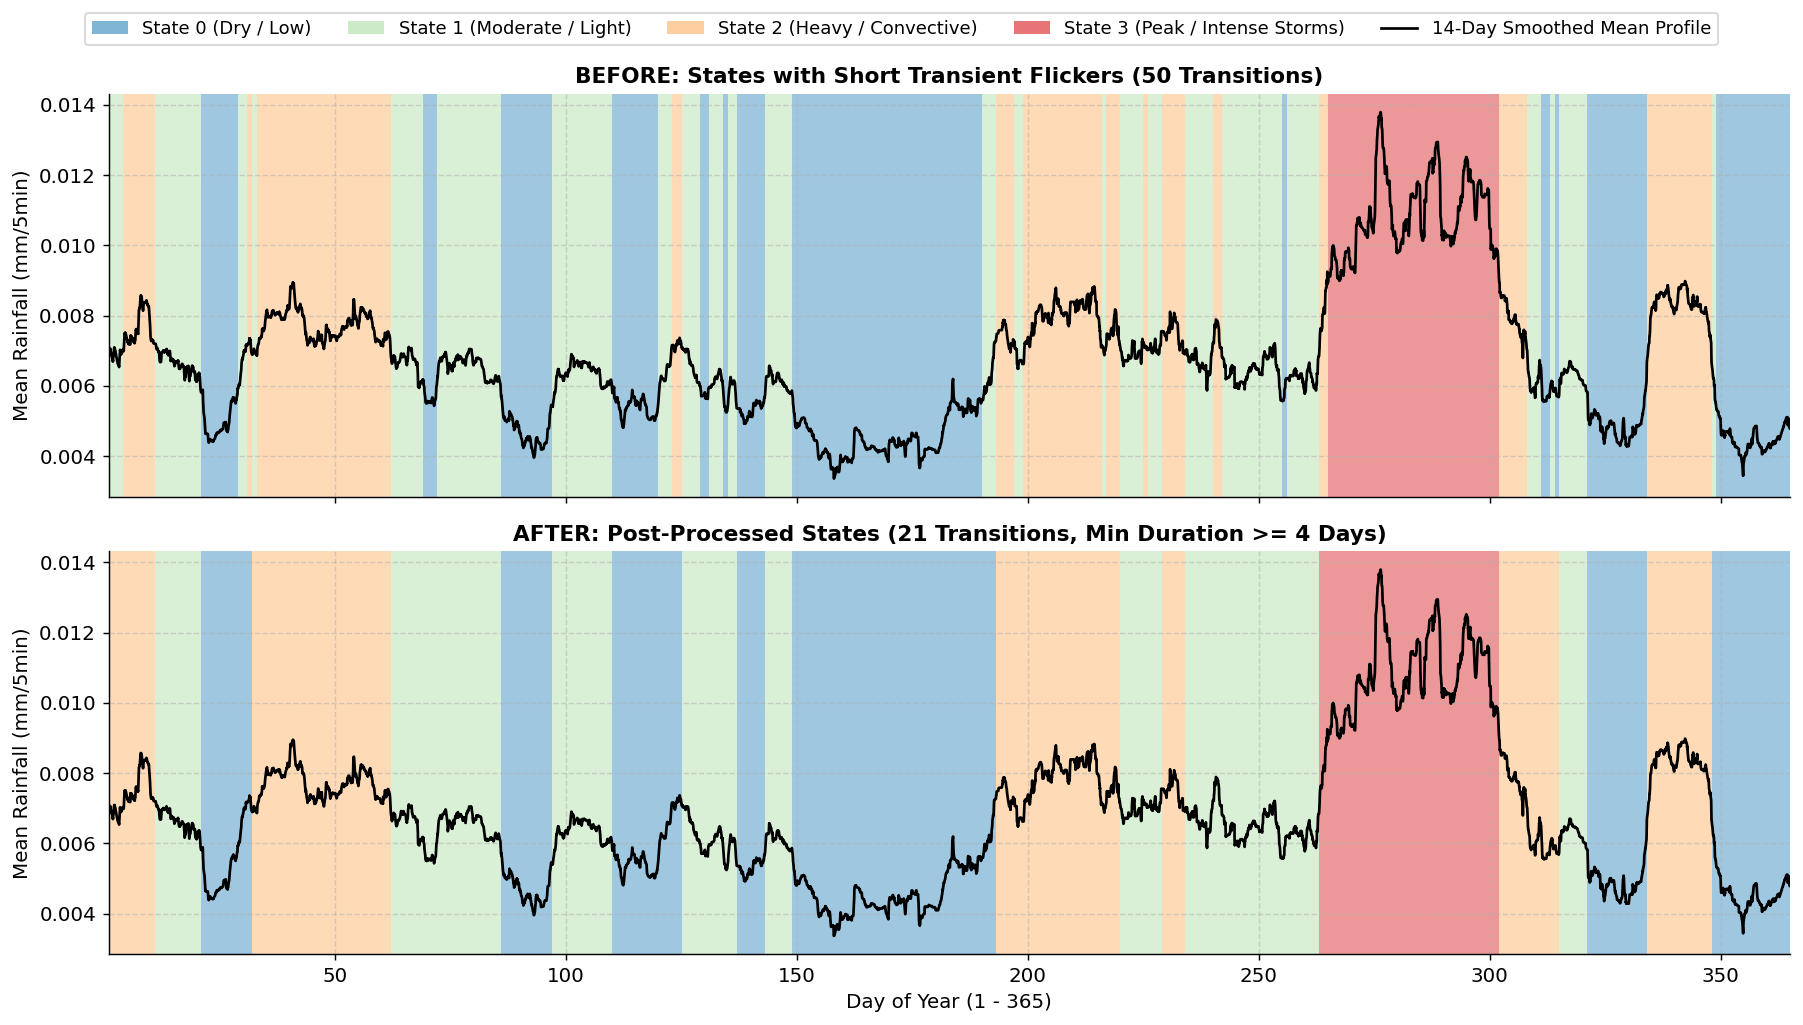

In [19]:
state_colors = {0: '#2b83ba', 1: '#abdda4', 2: '#fdae61', 3: '#d7191c'}
state_names = [
    'State 0 (Dry / Low)',
    'State 1 (Moderate / Light)',
    'State 2 (Heavy / Convective)',
    'State 3 (Peak / Intense Storms)'
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
days = clim_105120['annual_interval_idx'] / 288.0 + 1.0

# 1. Top Subplot: BEFORE (Raw HMM States with chattering)
cur_st = int(clim_105120['hmm_state_raw'].iloc[0])
st_idx = 0
for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state_raw'].iloc[i] != cur_st or i == len(clim_105120) - 1:
        ax1.axvspan(days.iloc[st_idx], days.iloc[i], color=state_colors[cur_st], alpha=0.45, linewidth=0)
        cur_st = int(clim_105120['hmm_state_raw'].iloc[i])
        st_idx = i

ax1.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=1.5)
ax1.set_title(f'BEFORE: States with Short Transient Flickers ({np.sum(clim_105120["hmm_state_raw"].values[:-1] != clim_105120["hmm_state_raw"].values[1:])} Transitions)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Rainfall (mm/5min)')
ax1.set_xlim(1, 365)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Bottom Subplot: AFTER (Post-Processed States >= min_days)
cur_st = int(clim_105120['hmm_state'].iloc[0])
st_idx = 0
for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != cur_st or i == len(clim_105120) - 1:
        ax2.axvspan(days.iloc[st_idx], days.iloc[i], color=state_colors[cur_st], alpha=0.45, linewidth=0)
        cur_st = int(clim_105120['hmm_state'].iloc[i])
        st_idx = i

ax2.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=1.5)
ax2.set_title(f'AFTER: Post-Processed States ({np.sum(clim_105120["hmm_state"].values[:-1] != clim_105120["hmm_state"].values[1:])} Transitions, Min Duration >= {floor(runs_df["dur_days"].median())} Days)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day of Year (1 - 365)')
ax2.set_ylabel('Mean Rainfall (mm/5min)')
ax2.set_xlim(1, 365)
ax2.grid(True, linestyle='--', alpha=0.5)

# Shared Legend
legend_elements = [Patch(facecolor=state_colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.5, label='14-Day Smoothed Mean Profile'))
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=5, fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 10. Out-of-Sample Label Assignment Across Splits
We project the post-processed 105,120 seasonal-phase map to all three splits by calendar interval position:
$$\text{annual\_interval\_idx} \mapsto \text{seasonal\_phase}$$
Holdout validation (2008) and test (2009) splits receive their conditioning labels strictly by their calendar slot without ever touching the model fitting or smoothing procedure.

In [21]:
# Create mapping dictionary from post-processed training climatology
interval_to_phase = dict(zip(clim_105120['annual_interval_idx'], clim_105120['hmm_state']))

# Map to all splits
splits = {'Train (2000-2007)': df_train, 'Val (2008)': df_val, 'Test (2009)': df_test}
for name, s_df in splits.items():
    s_df['hmm_state'] = s_df['annual_interval_idx'].map(interval_to_phase).astype(int)

# Verify label distribution across splits
print("Seasonal-Phase Distribution Across Splits (% of intervals):")
dist_table = pd.DataFrame()
for name, s_df in splits.items():
    dist_table[name] = (s_df['hmm_state'].value_counts(normalize=True).sort_index() * 100).round(2)
dist_table.index = [f"Phase {i}" for i in range(N_STATES)]
print(dist_table)

# Assertions
for name, s_df in splits.items():
    assert s_df['hmm_state'].isna().sum() == 0, f"NaNs found in {name}!"
    assert set(s_df['hmm_state'].unique()) == {0, 1, 2, 3}, f"Missing states in {name}!"
print("All splits successfully and cleanly labeled with zero leakage!")

Seasonal-Phase Distribution Across Splits (% of intervals):
         Train (2000-2007)  Val (2008)  Test (2009)
Phase 0              32.33       32.33        32.33
Phase 1              29.86       29.86        29.86
Phase 2              27.12       27.12        27.12
Phase 3              10.68       10.68        10.68
All splits successfully and cleanly labeled with zero leakage!


## 11. Multi-Scale Seasonal-Phase Block Transition Matrices (`seq_len` = 24 to 288)
When scaling model context from `seq_len = 24` ($2\text{ hours}$) up to `seq_len = 288` ($24\text{ hours}$ / full day), the block transition matrix must be calculated at the exact matching block duration:
- At `seq_len = 24`: $1\text{ step} = 2\text{ hours}$, so self-transition probability is $\sim 99.5\%$.
- At `seq_len = 288`: $1\text{ step} = 24\text{ hours}$, so self-transition probability is $\sim 94.0\%$.
Using a 24-step matrix for 288-step blocks would miscalibrate the Markov dwell time by $12\times$.

We compute and export transition matrices across all candidate window sizes:
$$\text{block\_size} \in \{1, 12, 24, 48, 72, 96, 144, 288\}$$

MULTI-SCALE BLOCK TRANSITION MATRIX PROPERTIES ACROSS CONTEXT LENGTHS
 seq_len (steps) Duration (hours)  Blocks / Year  Transitions / Year  Min Self-Trans (P_ii)  Mean Self-Trans (P_ii)
               1            0.1 h         105120                21.9                 0.9997                  0.9998
              12            1.0 h           8760                21.9                 0.9969                  0.9977
              24            2.0 h           4380                21.9                 0.9939                  0.9955
              48            4.0 h           2190                21.9                 0.9878                  0.9909
              72            6.0 h           1460                21.9                 0.9817                  0.9864
              96            8.0 h           1095                21.9                 0.9755                  0.9818
             144           12.0 h            730                21.9                 0.9633                  0.9728
  

<string>:137: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


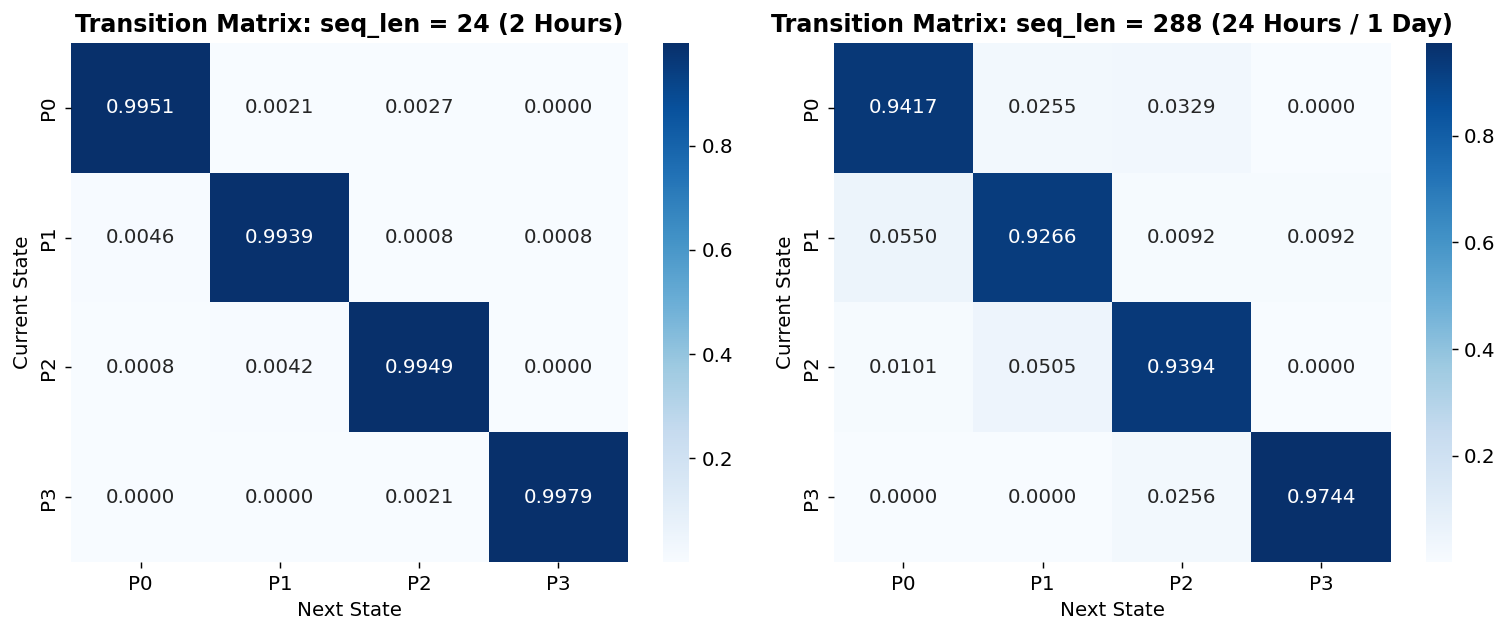

In [23]:
smooth = 1e-5
train_states = df_train['hmm_state'].values
candidate_block_sizes = [1, 12, 24, 48, 72, 96, 144, 288]

by_block_size = {}
summary_rows = []

for bs in candidate_block_sizes:
    n_blocks = len(train_states) // bs
    if bs == 1:
        block_seq = train_states
    elif 288 % bs == 0:
        # State is uniform within each day, so divisor chunks are uniform
        block_seq = train_states.reshape(n_blocks, bs)[:, 0]
    else:
        # Majority vote across chunk
        reshaped = train_states[:n_blocks * bs].reshape(n_blocks, bs)
        block_seq = np.array([pd.Series(row).mode()[0] for row in reshaped])
    
    # Count transitions with Laplace smoothing
    C_block = np.zeros((N_STATES, N_STATES), dtype=np.float64) + smooth
    for i in range(len(block_seq) - 1):
        s1, s2 = block_seq[i], block_seq[i + 1]
        if 0 <= s1 < N_STATES and 0 <= s2 < N_STATES:
            C_block[s1, s2] += 1.0
            
    P_block = C_block / C_block.sum(axis=1, keepdims=True)
    
    # Stationary distribution
    eigenvalues, eigenvectors = np.linalg.eig(P_block.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi_block = np.real(eigenvectors[:, idx])
    pi_block = np.abs(pi_block / np.sum(pi_block))
    
    n_trans = sum(1 for i in range(len(block_seq) - 1) if block_seq[i] != block_seq[i + 1])
    
    by_block_size[bs] = {
        'P_block': P_block,
        'P': P_block,
        'C_block': C_block,
        'pi_block': pi_block,
        'pi': pi_block,
        'block_size': bs,
        'duration_hours': bs * 5 / 60.0,
        'n_blocks_8yr': n_blocks,
        'blocks_per_year': n_blocks // 8,
        'n_transitions_8yr': n_trans,
        'transitions_per_year': n_trans / 8.0,
        'block_sequence': block_seq,
        'self_transition_diag': np.diag(P_block).tolist()
    }
    
    summary_rows.append({
        'seq_len (steps)': bs,
        'Duration (hours)': f"{bs * 5 / 60.0:.1f} h",
        'Blocks / Year': n_blocks // 8,
        'Transitions / Year': round(n_trans / 8.0, 1),
        'Min Self-Trans (P_ii)': round(np.diag(P_block).min(), 4),
        'Mean Self-Trans (P_ii)': round(np.diag(P_block).mean(), 4)
    })

df_trans_summary = pd.DataFrame(summary_rows)
print("=" * 90)
print("MULTI-SCALE BLOCK TRANSITION MATRIX PROPERTIES ACROSS CONTEXT LENGTHS")
print("=" * 90)
print(df_trans_summary.to_string(index=False))
print("=" * 90)

# Save Unified Multi-Scale Bundle (with top-level default for backward compatibility)
unique, counts = np.unique(train_states, return_counts=True)
regime_proportions = {int(r): float(c / len(train_states)) for r, c in zip(unique, counts)}

unified_bundle = {
    # Default top-level keys (block_size = 24 for backward compatibility with generate_hmm_v1.py)
    'P_block': by_block_size[24]['P_block'],
    'P': by_block_size[24]['P'],
    'C_block': by_block_size[24]['C_block'],
    'pi_block': by_block_size[24]['pi_block'],
    'pi': by_block_size[24]['pi'],
    'block_size': 24,
    'block_sequence': by_block_size[24]['block_sequence'],
    'n_blocks': by_block_size[24]['n_blocks_8yr'],
    'n_transitions': by_block_size[24]['n_transitions_8yr'],
    'regime_proportions': regime_proportions,
    'n_states': N_STATES,
    'post_processing_min_days': int(floor(runs_df['dur_days'].median())),
    # Multi-scale dictionary keyed by block_size / seq_len
    'by_block_size': by_block_size,
    'supported_block_sizes': candidate_block_sizes,
    # Deterministic 1-year calendar sequences for calendar-ordered assembly
    'calendar_sequence_1yr_step24': clim_105120['hmm_state'].values[::24],
    'calendar_sequence_1yr_step288': clim_105120['hmm_state'].values[::288],
}

main_pkl_path = os.path.join(SPLITS_DIR, 'seasonal_transition_matrix_train.pkl')
with open(main_pkl_path, 'wb') as f:
    pickle.dump(unified_bundle, f)
print(f"\n✓ Saved Unified Multi-Scale Matrix: {main_pkl_path}")

# Also save individual standalone pickles for specific seq_lens
for bs in [24, 48, 72, 96, 144, 288]:
    standalone = {
        'P_block': by_block_size[bs]['P_block'],
        'P': by_block_size[bs]['P'],
        'C_block': by_block_size[bs]['C_block'],
        'pi_block': by_block_size[bs]['pi_block'],
        'pi': by_block_size[bs]['pi'],
        'block_size': bs,
        'duration_hours': by_block_size[bs]['duration_hours'],
        'block_sequence': by_block_size[bs]['block_sequence'],
        'n_blocks': by_block_size[bs]['n_blocks_8yr'],
        'n_transitions': by_block_size[bs]['n_transitions_8yr'],
        'regime_proportions': regime_proportions,
        'n_states': N_STATES,
        'post_processing_min_days': int(floor(runs_df['dur_days'].median()))
    }
    sub_path = os.path.join(SPLITS_DIR, f'seasonal_transition_matrix_train_len{bs}.pkl')
    with open(sub_path, 'wb') as f:
        pickle.dump(standalone, f)
    print(f"✓ Saved Standalone Pickle for seq_len={bs:3d} ({bs*5/60.0:4.1f}h): {sub_path}")

# Plot transition matrix heatmaps for 24-step (2h) vs 288-step (24h)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(by_block_size[24]['P_block'], annot=True, fmt='.4f', cmap='Blues', ax=ax1,
            xticklabels=[f'P{i}' for i in range(4)], yticklabels=[f'P{i}' for i in range(4)])
ax1.set_title('Transition Matrix: seq_len = 24 (2 Hours)', fontweight='bold')
ax1.set_xlabel('Next State')
ax1.set_ylabel('Current State')

sns.heatmap(by_block_size[288]['P_block'], annot=True, fmt='.4f', cmap='Blues', ax=ax2,
            xticklabels=[f'P{i}' for i in range(4)], yticklabels=[f'P{i}' for i in range(4)])
ax2.set_title('Transition Matrix: seq_len = 288 (24 Hours / 1 Day)', fontweight='bold')
ax2.set_xlabel('Next State')
ax2.set_ylabel('Current State')

plt.tight_layout()
plt.show()

## 12. Clean Dataset & Manifest Export
We save standardized, holdout-aware CSV datasets into `data/rainfall/splits/`:
- `train_years_labelled.csv` ($840,960$ rows)
- `val_years_labelled.csv` ($105,120$ rows)
- `test_years_labelled.csv` ($105,120$ rows)
- `MANIFEST.json` documenting provenance, row counts, and checksums.

In [25]:
export_cols = ['datetime', 'date', 'avg_rainfall', 'rainfall_intensity', 'hmm_state', 'day_of_year', 'annual_interval_idx']

# Format date column for compatibility
for df_s in [df_train, df_val, df_test]:
    df_s['date'] = df_s['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')

train_csv = os.path.join(SPLITS_DIR, 'train_years_labelled.csv')
val_csv   = os.path.join(SPLITS_DIR, 'val_years_labelled.csv')
test_csv  = os.path.join(SPLITS_DIR, 'test_years_labelled.csv')

df_train[export_cols].to_csv(train_csv, index=False)
df_val[export_cols].to_csv(val_csv, index=False)
df_test[export_cols].to_csv(test_csv, index=False)

print(f"Saved {train_csv}: {len(df_train):,} rows")
print(f"Saved {val_csv}: {len(df_val):,} rows")
print(f"Saved {test_csv}: {len(df_test):,} rows")

def get_sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while c := f.read(65536):
            h.update(c)
    return h.hexdigest()

manifest = {
    'created_at': pd.Timestamp.now().isoformat(),
    'source_file': 'data/rainfall/real_rainfall_data.csv',
    'source_sha256': raw_sha256,
    'wet_threshold_mm': 0.005,
    'conditioning_mechanism': 'seasonal-phase-index',
    'post_processing': {
        'intra_day_mode_pooling': True,
        'min_duration_filter': 'smooth_hmm_states_min_duration',
        'min_days': int(floor(runs_df['dur_days'].median())),
        'annual_transitions': int(np.sum(clim_105120['hmm_state'].values[:-1] != clim_105120['hmm_state'].values[1:]))
    },
    'splits': {
        'train': {
            'file': 'train_years_labelled.csv',
            'years': '2000-2007',
            'rows': len(df_train),
            'sha256': get_sha256(train_csv),
            'phase_distribution': {int(k): int(v) for k, v in df_train['hmm_state'].value_counts().items()}
        },
        'val': {
            'file': 'val_years_labelled.csv',
            'years': '2008',
            'rows': len(df_val),
            'sha256': get_sha256(val_csv),
            'phase_distribution': {int(k): int(v) for k, v in df_val['hmm_state'].value_counts().items()}
        },
        'test': {
            'file': 'test_years_labelled.csv',
            'years': '2009',
            'rows': len(df_test),
            'sha256': get_sha256(test_csv),
            'phase_distribution': {int(k): int(v) for k, v in df_test['hmm_state'].value_counts().items()}
        }
    },
    'transition_matrices': {
        'unified_bundle': 'seasonal_transition_matrix_train.pkl',
        'supported_block_sizes': candidate_block_sizes,
        'standalone_files': {
            f'len{bs}': f'seasonal_transition_matrix_train_len{bs}.pkl'
            for bs in [24, 48, 72, 96, 144, 288]
        }
    }
}

manifest_path = os.path.join(SPLITS_DIR, 'MANIFEST.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"\nSuccessfully written MANIFEST.json to {manifest_path}")
print(json.dumps(manifest, indent=2))

Saved /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall/splits/train_years_labelled.csv: 840,960 rows
Saved /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall/splits/val_years_labelled.csv: 105,120 rows
Saved /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall/splits/test_years_labelled.csv: 105,120 rows

Successfully written MANIFEST.json to /Users/tanyawarrier/Desktop/projects/ImagenFew/data/rainfall/splits/MANIFEST.json
{
  "created_at": "2026-09-19T22:15:04.407140",
  "source_file": "data/rainfall/real_rainfall_data.csv",
  "source_sha256": "8f888e31edde837cb4fddad0c184e9ee15ca887690e21065dd75a06efeb3fffa",
  "wet_threshold_mm": 0.005,
  "conditioning_mechanism": "seasonal-phase-index",
  "post_processing": {
    "intra_day_mode_pooling": true,
    "min_duration_filter": "smooth_hmm_states_min_duration",
    "min_days": 4,
    "annual_transitions": 21
  },
  "splits": {
    "train": {
      "file": "train_years_labelled.csv",
      "years": "2000-2007"